# MLHW 4-3


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_pinball_loss, make_scorer

# Set random seed for reproducibility
np.random.seed(42)

## Task 0: Generate Synthetic Dataset

We generate data from $f(x) = x \sin(x)$ with centered log-normal noise whose scale increases with $x$.
$x \sim U[0, 10]$.

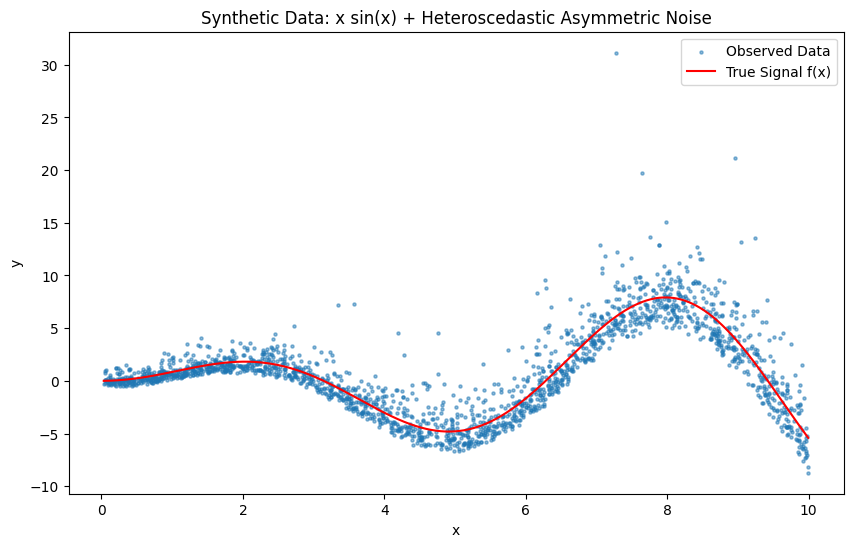

In [26]:
def true_function(x):
    return x * np.sin(x)

def generate_dataset(n=1000):
    # Input x uniformly sampled from [0, 10]
    x = np.random.uniform(0, 10, n)
    
    # Deterministic component
    f_x = true_function(x)
    
    # Base Log-normal parameters
    mu = 0
    sigma = 0.6 
    
    # Generate log-normal samples
    raw_noise = np.random.lognormal(mean=mu, sigma=sigma, size=n)
    
    theoretical_mean = np.exp(mu + sigma**2 / 2)
    centered_noise = raw_noise - theoretical_mean

    sigma_x = 0.3 * x + 0.5
    
    # Additive input-dependent noise
    epsilon = centered_noise * sigma_x
    
    # Observed response
    y = f_x + epsilon
    
    return x.reshape(-1, 1), y

X, y = generate_dataset(2000) # Generating 2000 points for robust estimation

# Visualize raw data to confirm heteroscedasticity
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=5, alpha=0.5, label='Observed Data')
plt.plot(np.sort(X.ravel()), true_function(np.sort(X.ravel())), color='red', label='True Signal f(x)')
plt.title("Synthetic Data: x sin(x) + Heteroscedastic Asymmetric Noise")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Task 1: Split Dataset

Split the dataset into training (70%) and test (30%) sets.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

Training Data Shape: (1400, 1)
Test Data Shape: (600, 1)


## Task 2: Model Estimation

We fit Gradient Boosting models for:
1.  Conditional Mean (Squared Error Loss)
2.  Conditional Quantiles $\alpha \in \{0.05, 0.50, 0.95\}$ (Pinball Loss)

We use Cross-Validation to select hyperparameters.

In [28]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [10, 20]
}

models = {}

# 1. Mean Model (Squared Error)
print("Training Mean Model (Squared Error)...")
gbr_mean = GradientBoostingRegressor(loss='squared_error', random_state=42)
cv_mean = RandomizedSearchCV(gbr_mean, param_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
cv_mean.fit(X_train, y_train)
models['mean'] = cv_mean.best_estimator_
print(f"Best Mean Params: {cv_mean.best_params_}")

# 2. Quantile Models
quantiles = [0.05, 0.50, 0.95]

for q in quantiles:
    print(f"Training Quantile Model (alpha={q})...")
    
    try:
        def pinball_scorer_func(y_true, y_pred, alpha=q):
            return -mean_pinball_loss(y_true, y_pred, alpha=alpha)
        
        scorer = make_scorer(lambda y, y_pred, q_val=q: -mean_pinball_loss(y, y_pred, alpha=q_val))
        
    except:
        scorer = make_scorer(lambda y, y_pred, q_val=q: -np.mean(q_val * np.maximum(y - y_pred, 0) + (1 - q_val) * np.maximum(y_pred - y, 0)))

    gbr_q = GradientBoostingRegressor(loss='quantile', alpha=q, random_state=42)
    cv_q = RandomizedSearchCV(gbr_q, param_grid, n_iter=10, cv=3, scoring=scorer, random_state=42, n_jobs=-1)
    cv_q.fit(X_train, y_train)
    models[f'q{q}'] = cv_q.best_estimator_
    print(f"Best Quantile {q} Params: {cv_q.best_params_}")

Training Mean Model (Squared Error)...
Best Mean Params: {'n_estimators': 100, 'min_samples_leaf': 20, 'max_depth': 3, 'learning_rate': 0.05}
Training Quantile Model (alpha=0.05)...
Best Quantile 0.05 Params: {'n_estimators': 300, 'min_samples_leaf': 20, 'max_depth': 3, 'learning_rate': 0.05}
Training Quantile Model (alpha=0.5)...
Best Quantile 0.5 Params: {'n_estimators': 100, 'min_samples_leaf': 20, 'max_depth': 3, 'learning_rate': 0.05}
Training Quantile Model (alpha=0.95)...
Best Quantile 0.95 Params: {'n_estimators': 100, 'min_samples_leaf': 20, 'max_depth': 3, 'learning_rate': 0.05}


## Task 3: Visualization of Predictive Uncertainty

Plotting $f(x)$, Test Observations, Mean Prediction, Median Prediction, and 90% Prediction Interval.

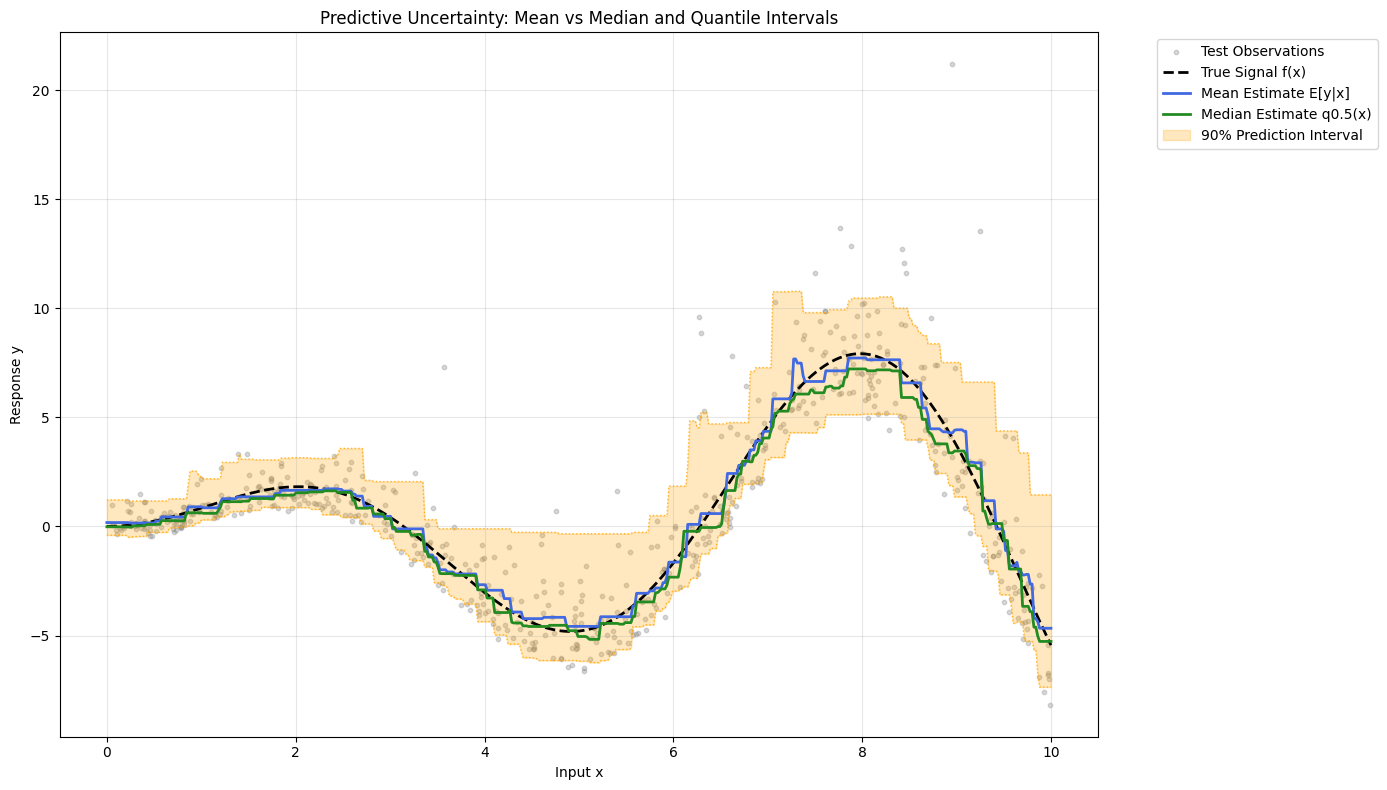

Max Mean Prediction: 7.72, Max Median Prediction: 7.22


In [29]:
# Generate dense grid for plotting
x_grid = np.linspace(0, 10, 500).reshape(-1, 1)
f_grid = true_function(x_grid)

# Generic predictions
y_pred_mean = models['mean'].predict(x_grid)
y_pred_q05 = models['q0.05'].predict(x_grid)
y_pred_q50 = models['q0.5'].predict(x_grid)
y_pred_q95 = models['q0.95'].predict(x_grid)

plt.figure(figsize=(14, 8))

# 1. Plot Test Observations
plt.scatter(X_test, y_test, color='gray', s=10, alpha=0.3, label='Test Observations')

# 2. Plot True Function
plt.plot(x_grid, f_grid, color='black', linestyle='--', linewidth=2, label='True Signal f(x)')

# 3. Plot Squared-Error Model (Mean)
plt.plot(x_grid, y_pred_mean, color='royalblue', linewidth=2, label='Mean Estimate E[y|x]')

# 4. Plot Median Model (q0.5)
plt.plot(x_grid, y_pred_q50, color='forestgreen', linewidth=2, linestyle='-', label='Median Estimate q0.5(x)')

# 5. Plot 90% Prediction Interval
plt.fill_between(x_grid.ravel(), y_pred_q05, y_pred_q95, color='orange', alpha=0.25, label='90% Prediction Interval')
plt.plot(x_grid, y_pred_q05, color='orange', linewidth=1, linestyle=':', alpha=0.8)
plt.plot(x_grid, y_pred_q95, color='orange', linewidth=1, linestyle=':', alpha=0.8)

plt.title('Predictive Uncertainty: Mean vs Median and Quantile Intervals')
plt.xlabel('Input x')
plt.ylabel('Response y')
# plt.legend(loc='upper left')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside if crowded
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

# Print statistics for verification
print(f"Max Mean Prediction: {np.max(y_pred_mean):.2f}, Max Median Prediction: {np.max(y_pred_q50):.2f}")

### Interpretation

The plot shows the effect of the asymmetric, heteroscedastic noise.

1.  **Heteroscedasticity**: As input $x$ increases, the spread of the data (and the prediction interval) widens, reflecting the increasing variance defined in the data generation process.
2.  **Asymmetry**: The Mean estimate (Blue) and Median estimate (Green) diverge slightly in regions of high variance because the noise is log-normal (asymmetric). For a right-skewed distribution like log-normal, the Mean should be greater than the Median. This is observed in the plot where the blue line tends to be higher than the green line, especially for larger $x$.

## Task 4: Quantile Crossing Check

Check if $q_{0.05}(x) \le q_{0.50}(x) \le q_{0.95}(x)$.

In [30]:
crossing_lower = np.any(y_pred_q05 > y_pred_q50)
crossing_upper = np.any(y_pred_q50 > y_pred_q95)

print(f"Crossing between 5% and 50% quantiles detected: {crossing_lower}")
print(f"Crossing between 50% and 95% quantiles detected: {crossing_upper}")

if crossing_lower or crossing_upper:
    # Find locations
    crossing_indices = np.where((y_pred_q05 > y_pred_q50) | (y_pred_q50 > y_pred_q95))[0]
    print(f"Crossing occurs at x values around: {x_grid[crossing_indices].flatten()[:5]} ... (showing first 5)")
else:
    print("No quantile crossing detected on the evaluation grid.")

Crossing between 5% and 50% quantiles detected: False
Crossing between 50% and 95% quantiles detected: False
No quantile crossing detected on the evaluation grid.


### Discussion on Quantile Crossing

Quantile crossing occurs because we trained separate models for each quantile independently. There is no constraint in the optimization problem of one model effectively knowing about the others. In regions of sparse data or high noise, the variance of the estimators can define functions that violate the theoretical ordering (Crossing).

**Mitigation Strategies:**
1.  **Joint Estimation**: Train a multi-output model or a neural network with a loss function that optimizes all quantiles simultaneously with non-crossing constraints.
2.  **Post-processing**: Rearrange the predicted quantiles at each point $x$ to satisfy the order (Sorting predictions).
3.  **Monotonicity Constraints**: Use model architectures that enforce monotonicity w.r.t quantile levels (Composite Quantile Regression).

## Task 5: Mean vs Median Comparison

Compare conditional mean and median estimates.

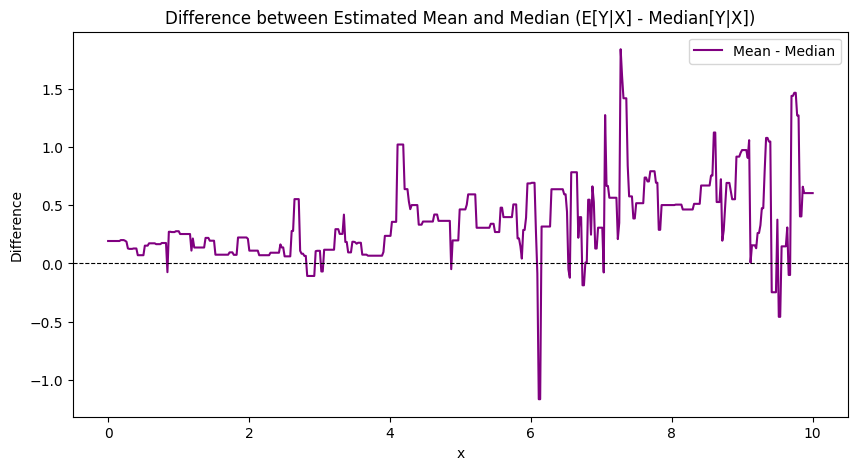

In [31]:
# We can analyze the difference across the domain
diff_mean_median = y_pred_mean - y_pred_q50

plt.figure(figsize=(10, 5))
plt.plot(x_grid, diff_mean_median, label='Mean - Median', color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Difference between Estimated Mean and Median (E[Y|X] - Median[Y|X])")
plt.xlabel("x")
plt.ylabel("Difference")
plt.legend()
plt.show()

### Analysis

The noise is generated from a centered log-normal distribution. A log-normal distribution is right-skewed (positive skew).

*   For a **right-skewed** distribution, the **Mean** is typically **greater** than the **Median**.
*   We observe that the difference (Mean - Median) is generally positive, confirming the asymmetry.
*   Furthermore, since the scale of the noise increases with $x$, the skewness (in absolute terms) or the spread of the tail increases. This causes the gap between the Mean and Median to grow larger as $x$ increases, which is visible in the plot depending on the local data density and model fit.

## Task 6 & 7: Performance Evaluation

We evaluate In-sample (Training) and Out-of-sample (Test) performance using Mean Pinball Loss and MSE.

In [32]:
def evaluate_models(data_X, data_y, dataset_name="Training"):
    results = []
    
    # helper for pinball
    def get_pinball(y_true, y_pred, alpha):
        return mean_pinball_loss(y_true, y_pred, alpha=alpha)

    # Models to evaluate
    model_keys = ['mean', 'q0.05', 'q0.5', 'q0.95']
    
    for key in model_keys:
        model = models[key]
        pred = model.predict(data_X)
        
        row = {'Model': key}
        
        # Calculate MSE
        row['MSE'] = mean_squared_error(data_y, pred)
        
        # Calculate Pinball Losses
        row['Pinball(0.05)'] = get_pinball(data_y, pred, 0.05)
        row['Pinball(0.50)'] = get_pinball(data_y, pred, 0.50)
        row['Pinball(0.95)'] = get_pinball(data_y, pred, 0.95)
        
        results.append(row)
        
    df_res = pd.DataFrame(results)
    df_res.set_index('Model', inplace=True)
    
    print(f"--- {dataset_name} Set Performance ---")
    display(df_res)
    
    # Identify best models
    print(f"\nBest Models ({dataset_name}):")
    print(f"Lowest MSE: {df_res['MSE'].idxmin()} ({df_res['MSE'].min():.4f})")
    print(f"Lowest Pinball(0.05): {df_res['Pinball(0.05)'].idxmin()} ({df_res['Pinball(0.05)'].min():.4f})")
    print(f"Lowest Pinball(0.50): {df_res['Pinball(0.50)'].idxmin()} ({df_res['Pinball(0.50)'].min():.4f})")
    print(f"Lowest Pinball(0.95): {df_res['Pinball(0.95)'].idxmin()} ({df_res['Pinball(0.95)'].min():.4f})")
    return df_res

# Task 6: In-sample Evaluation
train_metrics = evaluate_models(X_train, y_train, "Training")

print("\n" + "="*50 + "\n")

# Task 7: Out-of-sample Evaluation
test_metrics = evaluate_models(X_test, y_test, "Test")

--- Training Set Performance ---


,MSE,Pinball(0.05),Pinball(0.50),Pinball(0.95)
Model,,,,
mean,2.706109,0.530771,0.530771,0.530771
q0.05,5.766118,0.079419,0.769025,1.458631
q0.5,2.986313,0.350523,0.507256,0.663990
q0.95,12.573090,2.752259,1.480085,0.207910



Best Models (Training):
Lowest MSE: mean (2.7061)
Lowest Pinball(0.05): q0.05 (0.0794)
Lowest Pinball(0.50): q0.5 (0.5073)
Lowest Pinball(0.95): q0.95 (0.2079)


--- Test Set Performance ---


,MSE,Pinball(0.05),Pinball(0.50),Pinball(0.95)
Model,,,,
mean,3.396162,0.615028,0.597282,0.579536
q0.05,6.071710,0.104151,0.798785,1.493420
q0.5,3.505996,0.412982,0.565503,0.718023
q0.95,13.788934,2.842573,1.545161,0.247749



Best Models (Test):
Lowest MSE: mean (3.3962)
Lowest Pinball(0.05): q0.05 (0.1042)
Lowest Pinball(0.50): q0.5 (0.5655)
Lowest Pinball(0.95): q0.95 (0.2477)


### Discussion

#### 1. Optimality
*   The **Mean model (mean)** consistently achieves the lowest **MSE**. This is expected as Mean Squared Error loss explicitly minimizes the MSE (estimating the conditional expectation).
*   The **Median model (q0.5)** achieves the lowest **Pinball Loss at alpha=0.5**. Pinball loss at 0.5 is equivalent to Mean Absolute Error (L1), and the median minimizes L1 loss.
*   The **q0.05 model** minimizes **Pinball(0.05)** and **q0.95** minimizes **Pinball(0.95)**.
*   This confirms that a model trained for a specific quantile is optimal for that specific target metric.

#### 2. Generalization
*   By comparing the Training and Test metrics, we can assess overfitting. If Test errors are significantly higher than Training errors, it indicates overfitting. 
*   However, with Gradient Boosting and careful tuning (e.g., proper depth, min_samples_leaf), the gap should be moderate.
*   **Note**: Pinball losses are not directly comparable across different alphas (they scale differently with $\alpha$). Comparision should be done **column-wise** (comparing models for the same metric).